# HuggingFace Model Exploration for AMR Prediction

This notebook explores using pre-trained HuggingFace models for antimicrobial resistance prediction:

1. **ESM-2** (Evolutionary Scale Modeling) - Facebook's protein language model
2. **DNABERT-2** - DNA sequence transformer model

## Contents
1. [Setup & Model Download](#1-setup--model-download)
2. [ESM-2 Protein Embeddings](#2-esm-2-protein-embeddings)
3. [DNABERT-2 DNA Embeddings](#3-dnabert-2-dna-embeddings)
4. [Feature Extraction Pipeline](#4-feature-extraction-pipeline)
5. [Training AMR Classifier](#5-training-amr-classifier)
6. [Model Comparison](#6-model-comparison)
7. [Inference Pipeline](#7-inference-pipeline)
8. [Model Export](#8-model-export)

## 1. Setup & Model Download

In [1]:
# Standard imports
import sys
import os
import json
import warnings
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import joblib

# Sklearn imports
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path('.').absolute().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Project root: /Users/jubayer/Projects/DeepAMR
Timestamp: 2026-01-26 10:58:34


In [2]:
# Check PyTorch and HuggingFace availability
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 
                          'mps' if torch.backends.mps.is_available() else 'cpu')
    TORCH_AVAILABLE = True
    print(f"PyTorch version: {torch.__version__}")
    print(f"Device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available. Please install: pip install torch")

try:
    from transformers import AutoTokenizer, AutoModel, AutoConfig
    from transformers import EsmTokenizer, EsmModel
    import transformers
    TRANSFORMERS_AVAILABLE = True
    print(f"Transformers version: {transformers.__version__}")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("Transformers not available. Please install: pip install transformers")

try:
    from Bio import SeqIO
    from Bio.Seq import Seq
    BIOPYTHON_AVAILABLE = True
    print("BioPython available")
except ImportError:
    BIOPYTHON_AVAILABLE = False
    print("BioPython not available. Please install: pip install biopython")

PyTorch version: 2.10.0
Device: mps
Transformers not available. Please install: pip install transformers
BioPython available


In [3]:
# Define paths
DATA_DIR = project_root / 'data'
PROCESSED_DIR = DATA_DIR / 'processed' / 'ncbi'
GENOMES_DIR = DATA_DIR / 'raw' / 'ncbi' / 'genomes'
MODELS_DIR = project_root / 'models'
PRETRAINED_DIR = MODELS_DIR / 'pretrained'

# Create directories
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'huggingface').mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Pretrained models: {PRETRAINED_DIR}")
print(f"Genomes available: {GENOMES_DIR.exists()}")

Data directory: /Users/jubayer/Projects/DeepAMR/data
Pretrained models: /Users/jubayer/Projects/DeepAMR/models/pretrained
Genomes available: True


In [4]:
# Available ESM-2 models (from smallest to largest)
ESM2_MODELS = {
    '8M': 'facebook/esm2_t6_8M_UR50D',      # 6 layers, 8M params - fastest
    '35M': 'facebook/esm2_t12_35M_UR50D',   # 12 layers, 35M params - good balance
    '150M': 'facebook/esm2_t30_150M_UR50D', # 30 layers, 150M params
    '650M': 'facebook/esm2_t33_650M_UR50D', # 33 layers, 650M params - recommended
    '3B': 'facebook/esm2_t36_3B_UR50D',     # 36 layers, 3B params
}

# DNABERT-2 model
DNABERT2_MODEL = 'zhihan1996/DNABERT-2-117M'

# Select model size based on available resources
if TORCH_AVAILABLE:
    if torch.cuda.is_available():
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        if gpu_memory >= 16:
            SELECTED_ESM2_SIZE = '650M'
        elif gpu_memory >= 8:
            SELECTED_ESM2_SIZE = '150M'
        else:
            SELECTED_ESM2_SIZE = '35M'
        print(f"GPU Memory: {gpu_memory:.1f} GB")
    else:
        SELECTED_ESM2_SIZE = '35M'  # Use smaller model for CPU
else:
    SELECTED_ESM2_SIZE = '8M'

print(f"Selected ESM-2 model: {SELECTED_ESM2_SIZE} ({ESM2_MODELS[SELECTED_ESM2_SIZE]})")

Selected ESM-2 model: 35M (facebook/esm2_t12_35M_UR50D)


## 2. ESM-2 Protein Embeddings

ESM-2 (Evolutionary Scale Modeling) is a state-of-the-art protein language model trained on 250M protein sequences. It captures evolutionary and structural information without requiring multiple sequence alignment.

In [5]:
class ESM2FeatureExtractor:
    """
    Extract protein embeddings using ESM-2 model.
    
    ESM-2 is trained on UniRef50/UniRef90 protein sequences and captures
    evolutionary patterns useful for understanding protein function.
    """
    
    def __init__(self, model_size: str = '35M', cache_dir: Optional[Path] = None):
        """
        Initialize ESM-2 feature extractor.
        
        Args:
            model_size: One of '8M', '35M', '150M', '650M', '3B'
            cache_dir: Directory to cache downloaded models
        """
        if not TRANSFORMERS_AVAILABLE or not TORCH_AVAILABLE:
            raise ImportError("PyTorch and Transformers required")
        
        self.model_size = model_size
        self.model_name = ESM2_MODELS.get(model_size, ESM2_MODELS['35M'])
        self.cache_dir = cache_dir or PRETRAINED_DIR / f'esm2_{model_size}'
        self.device = DEVICE
        
        print(f"Loading ESM-2 {model_size} from {self.model_name}...")
        self._load_model()
        
    def _load_model(self):
        """Load tokenizer and model."""
        # Check if model is cached locally
        if self.cache_dir.exists() and (self.cache_dir / 'config.json').exists():
            print(f"Loading from cache: {self.cache_dir}")
            self.tokenizer = AutoTokenizer.from_pretrained(str(self.cache_dir))
            self.model = AutoModel.from_pretrained(str(self.cache_dir))
        else:
            print(f"Downloading from HuggingFace Hub...")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModel.from_pretrained(self.model_name)
            
            # Cache locally
            self.cache_dir.mkdir(parents=True, exist_ok=True)
            self.tokenizer.save_pretrained(str(self.cache_dir))
            self.model.save_pretrained(str(self.cache_dir))
            print(f"Model cached to: {self.cache_dir}")
        
        self.model = self.model.to(self.device)
        self.model.eval()
        
        # Get embedding dimension
        self.embedding_dim = self.model.config.hidden_size
        print(f"Model loaded! Embedding dimension: {self.embedding_dim}")
    
    def get_embedding(self, protein_sequence: str, pooling: str = 'mean') -> np.ndarray:
        """
        Get embedding for a single protein sequence.
        
        Args:
            protein_sequence: Amino acid sequence (e.g., 'MKTAYIAK...')
            pooling: 'mean', 'cls', or 'max'
            
        Returns:
            Embedding vector of shape (embedding_dim,)
        """
        # Truncate if too long (ESM-2 max length is 1024)
        max_length = 1022  # Leave room for special tokens
        if len(protein_sequence) > max_length:
            protein_sequence = protein_sequence[:max_length]
        
        # Tokenize
        inputs = self.tokenizer(
            protein_sequence,
            return_tensors='pt',
            truncation=True,
            max_length=1024,
            padding=False
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        # Get embeddings
        with torch.no_grad():
            outputs = self.model(**inputs)
            hidden_states = outputs.last_hidden_state  # (1, seq_len, hidden_size)
        
        # Pooling
        if pooling == 'cls':
            # Use CLS token (first token)
            embedding = hidden_states[:, 0, :]
        elif pooling == 'max':
            # Max pooling
            embedding = hidden_states.max(dim=1)[0]
        else:  # mean
            # Mean pooling (excluding special tokens)
            attention_mask = inputs.get('attention_mask', torch.ones_like(inputs['input_ids']))
            mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            sum_embeddings = torch.sum(hidden_states * mask, dim=1)
            sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
            embedding = sum_embeddings / sum_mask
        
        return embedding.cpu().numpy().squeeze()
    
    def get_batch_embeddings(self, sequences: List[str], batch_size: int = 8,
                             pooling: str = 'mean', show_progress: bool = True) -> np.ndarray:
        """
        Get embeddings for multiple sequences.
        
        Args:
            sequences: List of protein sequences
            batch_size: Number of sequences per batch
            pooling: Pooling strategy
            show_progress: Show progress bar
            
        Returns:
            Array of shape (n_sequences, embedding_dim)
        """
        embeddings = []
        iterator = range(0, len(sequences), batch_size)
        if show_progress:
            iterator = tqdm(iterator, desc='Extracting ESM-2 embeddings')
        
        for i in iterator:
            batch = sequences[i:i+batch_size]
            batch_embeddings = [self.get_embedding(seq, pooling) for seq in batch]
            embeddings.extend(batch_embeddings)
        
        return np.array(embeddings)

print("ESM2FeatureExtractor class defined.")

ESM2FeatureExtractor class defined.


In [6]:
# Test ESM-2 feature extraction
if TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE:
    print("Testing ESM-2 feature extraction...")
    
    # Initialize extractor (use smallest model for testing)
    esm2_extractor = ESM2FeatureExtractor(model_size='8M')
    
    # Test sequences (known AMR-related proteins)
    test_proteins = [
        # Beta-lactamase (TEM-1) - confers resistance to beta-lactam antibiotics
        "MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPVAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW",
        # Aminoglycoside acetyltransferase - confers resistance to aminoglycosides
        "MTEQNTPNKAELSAKLIEEVAKDGFGGKDHLWYHVLGDHRRPGQDSRLRLRVSPGQPVLVRAATGGGVSHGSLHMLSGARHFHRMPTTALLQLDELHLVHAAGHWLGDARDAFKRLVNAGLGQPHSVTLVSRLPAHPPLPPAAAAATLTLPAALTTLPVSKTG",
    ]
    
    for i, seq in enumerate(test_proteins):
        embedding = esm2_extractor.get_embedding(seq)
        print(f"\nProtein {i+1}:")
        print(f"  Sequence length: {len(seq)} aa")
        print(f"  Embedding shape: {embedding.shape}")
        print(f"  Embedding mean: {embedding.mean():.4f}")
        print(f"  Embedding std: {embedding.std():.4f}")
else:
    print("Skipping ESM-2 test (PyTorch/Transformers not available)")

Skipping ESM-2 test (PyTorch/Transformers not available)


## 3. DNABERT-2 DNA Embeddings

DNABERT-2 is a transformer model specifically trained on DNA sequences. It uses Byte Pair Encoding (BPE) tokenization rather than k-mers, making it more efficient and effective for DNA sequence understanding.

In [7]:
class DNABERT2FeatureExtractor:
    """
    Extract DNA sequence embeddings using DNABERT-2.
    
    DNABERT-2 uses BPE tokenization and is trained on diverse DNA sequences,
    making it effective for genomic analysis tasks.
    """
    
    def __init__(self, cache_dir: Optional[Path] = None):
        """
        Initialize DNABERT-2 feature extractor.
        
        Args:
            cache_dir: Directory to cache downloaded models
        """
        if not TRANSFORMERS_AVAILABLE or not TORCH_AVAILABLE:
            raise ImportError("PyTorch and Transformers required")
        
        self.model_name = DNABERT2_MODEL
        self.cache_dir = cache_dir or PRETRAINED_DIR / 'dnabert2'
        self.device = DEVICE
        
        print(f"Loading DNABERT-2 from {self.model_name}...")
        self._load_model()
    
    def _load_model(self):
        """Load tokenizer and model."""
        # Check if model is cached locally
        if self.cache_dir.exists() and (self.cache_dir / 'config.json').exists():
            print(f"Loading from cache: {self.cache_dir}")
            self.tokenizer = AutoTokenizer.from_pretrained(
                str(self.cache_dir), trust_remote_code=True
            )
            self.model = AutoModel.from_pretrained(
                str(self.cache_dir), trust_remote_code=True
            )
        else:
            print(f"Downloading from HuggingFace Hub...")
            self.tokenizer = AutoTokenizer.from_pretrained(
                self.model_name, trust_remote_code=True
            )
            self.model = AutoModel.from_pretrained(
                self.model_name, trust_remote_code=True
            )
            
            # Cache locally
            self.cache_dir.mkdir(parents=True, exist_ok=True)
            self.tokenizer.save_pretrained(str(self.cache_dir))
            self.model.save_pretrained(str(self.cache_dir))
            print(f"Model cached to: {self.cache_dir}")
        
        self.model = self.model.to(self.device)
        self.model.eval()
        
        # Get embedding dimension
        self.embedding_dim = self.model.config.hidden_size
        print(f"Model loaded! Embedding dimension: {self.embedding_dim}")
    
    def get_embedding(self, dna_sequence: str, pooling: str = 'mean') -> np.ndarray:
        """
        Get embedding for a DNA sequence.
        
        Args:
            dna_sequence: DNA sequence (e.g., 'ATGCGATCG...')
            pooling: 'mean', 'cls', or 'max'
            
        Returns:
            Embedding vector
        """
        # Clean sequence (uppercase, only ATCG)
        dna_sequence = dna_sequence.upper()
        dna_sequence = ''.join(c for c in dna_sequence if c in 'ATCG')
        
        # Truncate if too long
        max_length = 512  # DNABERT-2 typically uses 512 max length
        if len(dna_sequence) > max_length:
            dna_sequence = dna_sequence[:max_length]
        
        # Tokenize
        inputs = self.tokenizer(
            dna_sequence,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=False
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        # Get embeddings
        with torch.no_grad():
            outputs = self.model(**inputs)
            hidden_states = outputs.last_hidden_state
        
        # Pooling
        if pooling == 'cls':
            embedding = hidden_states[:, 0, :]
        elif pooling == 'max':
            embedding = hidden_states.max(dim=1)[0]
        else:  # mean
            embedding = hidden_states.mean(dim=1)
        
        return embedding.cpu().numpy().squeeze()
    
    def get_genome_embedding(self, genome_sequence: str, chunk_size: int = 500,
                              stride: int = 250, max_chunks: int = 100) -> np.ndarray:
        """
        Get embedding for a full genome by chunking and aggregating.
        
        Args:
            genome_sequence: Full genome sequence
            chunk_size: Size of each chunk
            stride: Stride between chunks
            max_chunks: Maximum number of chunks to process
            
        Returns:
            Aggregated embedding vector
        """
        # Clean sequence
        genome_sequence = genome_sequence.upper()
        genome_sequence = ''.join(c for c in genome_sequence if c in 'ATCG')
        
        # Create chunks
        chunks = []
        for i in range(0, len(genome_sequence) - chunk_size, stride):
            chunks.append(genome_sequence[i:i+chunk_size])
            if len(chunks) >= max_chunks:
                break
        
        if len(chunks) == 0:
            chunks = [genome_sequence[:chunk_size]]
        
        # Get embeddings for all chunks
        embeddings = []
        for chunk in chunks:
            try:
                emb = self.get_embedding(chunk)
                embeddings.append(emb)
            except Exception as e:
                continue
        
        if len(embeddings) == 0:
            return np.zeros(self.embedding_dim)
        
        # Aggregate (mean pooling across chunks)
        return np.mean(embeddings, axis=0)

print("DNABERT2FeatureExtractor class defined.")

DNABERT2FeatureExtractor class defined.


In [8]:
# Test DNABERT-2 feature extraction
if TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE:
    print("Testing DNABERT-2 feature extraction...")
    print("Note: DNABERT-2 requires trust_remote_code=True")
    
    try:
        dnabert2_extractor = DNABERT2FeatureExtractor()
        
        # Test DNA sequences
        test_dna = [
            # blaTEM-1 gene (beta-lactamase)
            "ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGGCATTTTGCCTTCCTGTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCACGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCGCCCCGAAGAACGTTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCCCGTATTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTGGTTGAGTACTCACCAGTCACAGAAAAGCATCTTACGGATGGCATGACAGTAAGAGAATTATGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATCGGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGTAACTCGCCTTGATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGTAGCAATGGCAACAACGTTGCGCAAACTATTAACTGGCGAACTACTTACTCTAGCTTCCCGGCAACAATTAATAGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGCTCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCGTATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAA",
            # Random control sequence
            "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATC"
        ]
        
        for i, seq in enumerate(test_dna):
            embedding = dnabert2_extractor.get_embedding(seq)
            print(f"\nDNA sequence {i+1}:")
            print(f"  Sequence length: {len(seq)} bp")
            print(f"  Embedding shape: {embedding.shape}")
            print(f"  Embedding mean: {embedding.mean():.4f}")
            print(f"  Embedding std: {embedding.std():.4f}")
            
    except Exception as e:
        print(f"DNABERT-2 test failed: {e}")
        print("This is expected if the model hasn't been downloaded yet.")
        dnabert2_extractor = None
else:
    print("Skipping DNABERT-2 test (PyTorch/Transformers not available)")
    dnabert2_extractor = None

Skipping DNABERT-2 test (PyTorch/Transformers not available)


## 4. Feature Extraction Pipeline

Combined feature extraction from genome sequences using both protein and DNA embeddings.

In [9]:
class GenomicFeatureExtractor:
    """
    Combined feature extraction from genomes using HuggingFace models.
    
    Extracts:
    1. Protein embeddings from translated ORFs using ESM-2
    2. DNA embeddings from genome chunks using DNABERT-2
    """
    
    CODON_TABLE = {
        'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
        'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
        'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
        'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
        'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
        'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
        'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
        'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
        'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
        'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
        'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
        'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
        'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
        'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
        'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
        'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
    }
    
    def __init__(self, 
                 use_esm2: bool = True,
                 use_dnabert2: bool = False,
                 esm2_size: str = '8M'):
        """
        Initialize feature extractor.
        
        Args:
            use_esm2: Use ESM-2 for protein embeddings
            use_dnabert2: Use DNABERT-2 for DNA embeddings
            esm2_size: ESM-2 model size
        """
        self.use_esm2 = use_esm2
        self.use_dnabert2 = use_dnabert2
        
        self.esm2_extractor = None
        self.dnabert2_extractor = None
        
        if use_esm2 and TRANSFORMERS_AVAILABLE:
            self.esm2_extractor = ESM2FeatureExtractor(model_size=esm2_size)
        
        if use_dnabert2 and TRANSFORMERS_AVAILABLE:
            try:
                self.dnabert2_extractor = DNABERT2FeatureExtractor()
            except Exception as e:
                print(f"Could not load DNABERT-2: {e}")
                self.use_dnabert2 = False
        
        # Calculate total feature dimension
        self.feature_dim = 0
        if self.esm2_extractor:
            self.feature_dim += self.esm2_extractor.embedding_dim
        if self.dnabert2_extractor:
            self.feature_dim += self.dnabert2_extractor.embedding_dim
        
        print(f"Total feature dimension: {self.feature_dim}")
    
    def translate_dna(self, dna_seq: str) -> str:
        """Translate DNA to protein sequence."""
        protein = []
        dna_seq = dna_seq.upper()
        
        for i in range(0, len(dna_seq) - 2, 3):
            codon = dna_seq[i:i+3]
            if codon in self.CODON_TABLE:
                aa = self.CODON_TABLE[codon]
                if aa == '*':
                    break
                protein.append(aa)
        
        return ''.join(protein)
    
    def find_orfs(self, sequence: str, min_length: int = 100) -> List[str]:
        """
        Find open reading frames in a DNA sequence.
        
        Args:
            sequence: DNA sequence
            min_length: Minimum ORF length in amino acids
            
        Returns:
            List of protein sequences from ORFs
        """
        proteins = []
        sequence = sequence.upper()
        stop_codons = {'TAA', 'TAG', 'TGA'}
        
        # Search all 3 reading frames on forward strand
        for frame in range(3):
            i = frame
            while i < len(sequence) - 3:
                codon = sequence[i:i+3]
                if codon == 'ATG':  # Start codon
                    # Find stop codon
                    for j in range(i+3, len(sequence)-2, 3):
                        stop_codon = sequence[j:j+3]
                        if stop_codon in stop_codons:
                            orf = sequence[i:j+3]
                            if len(orf) >= min_length * 3:
                                protein = self.translate_dna(orf)
                                if len(protein) >= min_length:
                                    proteins.append(protein)
                            i = j + 3
                            break
                    else:
                        i += 3
                else:
                    i += 3
        
        return proteins
    
    def extract_features(self, genome_path: str, max_proteins: int = 20) -> Dict:
        """
        Extract features from a genome file.
        
        Args:
            genome_path: Path to FASTA file
            max_proteins: Maximum number of proteins to embed
            
        Returns:
            Dictionary with features and metadata
        """
        # Load genome
        genome_seq = ""
        if BIOPYTHON_AVAILABLE:
            import gzip
            try:
                if str(genome_path).endswith('.gz'):
                    with gzip.open(genome_path, 'rt') as f:
                        for record in SeqIO.parse(f, 'fasta'):
                            genome_seq += str(record.seq)
                else:
                    for record in SeqIO.parse(genome_path, 'fasta'):
                        genome_seq += str(record.seq)
            except Exception as e:
                print(f"Error loading genome: {e}")
                return None
        
        if len(genome_seq) == 0:
            print(f"Empty genome: {genome_path}")
            return None
        
        features = []
        
        # ESM-2 protein embeddings
        if self.esm2_extractor:
            proteins = self.find_orfs(genome_seq, min_length=50)
            proteins = proteins[:max_proteins]
            
            if len(proteins) > 0:
                protein_embeddings = []
                for prot in proteins:
                    try:
                        emb = self.esm2_extractor.get_embedding(prot)
                        protein_embeddings.append(emb)
                    except:
                        continue
                
                if len(protein_embeddings) > 0:
                    esm2_features = np.mean(protein_embeddings, axis=0)
                else:
                    esm2_features = np.zeros(self.esm2_extractor.embedding_dim)
            else:
                esm2_features = np.zeros(self.esm2_extractor.embedding_dim)
            
            features.append(esm2_features)
        
        # DNABERT-2 DNA embeddings
        if self.dnabert2_extractor:
            dnabert_features = self.dnabert2_extractor.get_genome_embedding(genome_seq)
            features.append(dnabert_features)
        
        # Concatenate all features
        if len(features) == 0:
            return None
        
        combined_features = np.concatenate(features)
        
        return {
            'features': combined_features,
            'genome_length': len(genome_seq),
            'n_proteins': len(proteins) if self.esm2_extractor else 0,
            'feature_dim': len(combined_features)
        }

print("GenomicFeatureExtractor class defined.")

GenomicFeatureExtractor class defined.


## 5. Training AMR Classifier

Train classifiers on HuggingFace embeddings for AMR prediction.

In [10]:
class HuggingFaceAMRClassifier:
    """
    AMR classifier using HuggingFace model embeddings.
    
    This classifier:
    1. Extracts embeddings from genomes using ESM-2/DNABERT-2
    2. Trains a sklearn classifier on the embeddings
    3. Predicts AMR phenotypes for new genomes
    """
    
    def __init__(self, 
                 task_type: str = 'multiclass',
                 classifier_type: str = 'random_forest',
                 use_esm2: bool = True,
                 use_dnabert2: bool = False,
                 esm2_size: str = '8M'):
        """
        Initialize AMR classifier.
        
        Args:
            task_type: 'multiclass' or 'multilabel'
            classifier_type: 'random_forest', 'logistic_regression', 'mlp'
            use_esm2: Use ESM-2 embeddings
            use_dnabert2: Use DNABERT-2 embeddings
            esm2_size: ESM-2 model size
        """
        self.task_type = task_type
        self.classifier_type = classifier_type
        
        # Initialize feature extractor
        self.feature_extractor = GenomicFeatureExtractor(
            use_esm2=use_esm2,
            use_dnabert2=use_dnabert2,
            esm2_size=esm2_size
        )
        
        # Initialize classifier
        self.classifier = self._create_classifier()
        self.scaler = StandardScaler()
        self.is_fitted = False
    
    def _create_classifier(self):
        """Create sklearn classifier."""
        classifiers = {
            'random_forest': RandomForestClassifier(
                n_estimators=200, max_depth=20, n_jobs=-1, 
                random_state=42, class_weight='balanced'
            ),
            'logistic_regression': LogisticRegression(
                max_iter=1000, random_state=42, class_weight='balanced'
            ),
            'mlp': MLPClassifier(
                hidden_layer_sizes=(256, 128, 64), max_iter=500,
                random_state=42, early_stopping=True
            ),
            'gradient_boosting': GradientBoostingClassifier(
                n_estimators=100, max_depth=5, random_state=42
            )
        }
        
        clf = classifiers.get(self.classifier_type, classifiers['random_forest'])
        
        if self.task_type == 'multilabel':
            clf = OneVsRestClassifier(clf, n_jobs=-1)
        
        return clf
    
    def extract_features_batch(self, genome_paths: List[str], 
                                show_progress: bool = True) -> np.ndarray:
        """
        Extract features for a batch of genomes.
        
        Args:
            genome_paths: List of paths to genome FASTA files
            show_progress: Show progress bar
            
        Returns:
            Feature matrix of shape (n_samples, n_features)
        """
        features = []
        valid_indices = []
        
        iterator = enumerate(genome_paths)
        if show_progress:
            iterator = tqdm(list(iterator), desc='Extracting features')
        
        for i, path in iterator:
            result = self.feature_extractor.extract_features(path)
            if result is not None:
                features.append(result['features'])
                valid_indices.append(i)
        
        if len(features) == 0:
            return np.array([]), []
        
        return np.array(features), valid_indices
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit the classifier on pre-extracted features.
        
        Args:
            X: Feature matrix
            y: Labels
        """
        print(f"Fitting {self.classifier_type} classifier...")
        print(f"  X shape: {X.shape}")
        print(f"  y shape: {y.shape}")
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Fit classifier
        self.classifier.fit(X_scaled, y)
        self.is_fitted = True
        
        print("Classifier fitted successfully!")
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Make predictions on pre-extracted features."""
        if not self.is_fitted:
            raise ValueError("Classifier not fitted. Call fit() first.")
        
        X_scaled = self.scaler.transform(X)
        return self.classifier.predict(X_scaled)
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Get prediction probabilities."""
        if not self.is_fitted:
            raise ValueError("Classifier not fitted. Call fit() first.")
        
        X_scaled = self.scaler.transform(X)
        proba = self.classifier.predict_proba(X_scaled)
        
        if isinstance(proba, list):
            proba = np.array([p[:, 1] for p in proba]).T
        
        return proba
    
    def evaluate(self, X: np.ndarray, y_true: np.ndarray) -> Dict:
        """Evaluate classifier performance."""
        y_pred = self.predict(X)
        
        if self.task_type == 'multilabel':
            metrics = {
                'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
                'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
                'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            }
        else:
            metrics = {
                'accuracy': accuracy_score(y_true, y_pred),
                'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
                'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
            }
        
        return metrics
    
    def save(self, filepath: str):
        """Save classifier (not feature extractor)."""
        joblib.dump({
            'classifier': self.classifier,
            'scaler': self.scaler,
            'task_type': self.task_type,
            'classifier_type': self.classifier_type,
            'is_fitted': self.is_fitted
        }, filepath)
        print(f"Classifier saved to {filepath}")
    
    @classmethod
    def load(cls, filepath: str, **kwargs):
        """Load saved classifier."""
        data = joblib.load(filepath)
        
        instance = cls(
            task_type=data['task_type'],
            classifier_type=data['classifier_type'],
            **kwargs
        )
        instance.classifier = data['classifier']
        instance.scaler = data['scaler']
        instance.is_fitted = data['is_fitted']
        
        return instance

print("HuggingFaceAMRClassifier class defined.")

HuggingFaceAMRClassifier class defined.


In [11]:
# Load existing processed data for comparison
print("Loading existing processed data...")

try:
    # Load organism classification data
    X_train_org = np.load(PROCESSED_DIR / 'ncbi_organism_X_train.npy')
    X_val_org = np.load(PROCESSED_DIR / 'ncbi_organism_X_val.npy')
    X_test_org = np.load(PROCESSED_DIR / 'ncbi_organism_X_test.npy')
    y_train_org = np.load(PROCESSED_DIR / 'ncbi_organism_y_train.npy')
    y_val_org = np.load(PROCESSED_DIR / 'ncbi_organism_y_val.npy')
    y_test_org = np.load(PROCESSED_DIR / 'ncbi_organism_y_test.npy')
    
    with open(PROCESSED_DIR / 'ncbi_organism_metadata.json') as f:
        organism_metadata = json.load(f)
    
    print(f"Organism data: {X_train_org.shape[0]} train, {X_test_org.shape[0]} test")
    print(f"Classes: {organism_metadata['class_names']}")
    
    # Load AMR prediction data
    X_train_amr = np.load(PROCESSED_DIR / 'ncbi_amr_X_train.npy')
    X_val_amr = np.load(PROCESSED_DIR / 'ncbi_amr_X_val.npy')
    X_test_amr = np.load(PROCESSED_DIR / 'ncbi_amr_X_test.npy')
    y_train_amr = np.load(PROCESSED_DIR / 'ncbi_amr_y_train.npy')
    y_val_amr = np.load(PROCESSED_DIR / 'ncbi_amr_y_val.npy')
    y_test_amr = np.load(PROCESSED_DIR / 'ncbi_amr_y_test.npy')
    
    with open(PROCESSED_DIR / 'ncbi_amr_metadata.json') as f:
        amr_metadata = json.load(f)
    
    print(f"AMR data: {X_train_amr.shape[0]} train, {X_test_amr.shape[0]} test")
    print(f"Drug classes: {amr_metadata['class_names']}")
    
    DATA_LOADED = True
    
except FileNotFoundError as e:
    print(f"Processed data not found: {e}")
    print("Please run notebook 04_ncbi_data_exploration.ipynb first.")
    DATA_LOADED = False

Loading existing processed data...
Organism data: 602 train, 173 test
Classes: ['Acinetobacter baumannii', 'Enterococcus faecalis', 'Enterococcus faecium', 'Escherichia coli', 'Klebsiella pneumoniae', 'Pseudomonas aeruginosa', 'Salmonella enterica', 'Staphylococcus aureus']
AMR data: 602 train, 173 test
Drug classes: ['aminoglycoside', 'beta-lactam', 'fosfomycin', 'glycopeptide', 'macrolide', 'phenicol', 'quinolone', 'rifampicin', 'sulfonamide', 'tetracycline', 'trimethoprim']


## 6. Model Comparison

Compare HuggingFace embeddings with K-mer features for AMR prediction.

In [12]:
# Compare different approaches on the existing k-mer data
# This demonstrates how HuggingFace classifiers can be used

if DATA_LOADED and TORCH_AVAILABLE:
    print("="*60)
    print("Comparing Classifiers on K-mer Features")
    print("="*60)
    
    results = []
    
    # Test different classifier types
    classifier_types = ['random_forest', 'logistic_regression', 'mlp']
    
    for clf_type in classifier_types:
        print(f"\n--- {clf_type.upper()} ---")
        
        # Create classifier (without HuggingFace models for k-mer data)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_org)
        X_test_scaled = scaler.transform(X_test_org)
        
        if clf_type == 'random_forest':
            clf = RandomForestClassifier(n_estimators=200, max_depth=20, 
                                         n_jobs=-1, random_state=42)
        elif clf_type == 'logistic_regression':
            clf = LogisticRegression(max_iter=1000, random_state=42)
        else:
            clf = MLPClassifier(hidden_layer_sizes=(256, 128, 64), 
                               max_iter=500, random_state=42, early_stopping=True)
        
        # Train
        clf.fit(X_train_scaled, y_train_org)
        
        # Evaluate
        y_pred = clf.predict(X_test_scaled)
        
        acc = accuracy_score(y_test_org, y_pred)
        f1 = f1_score(y_test_org, y_pred, average='weighted')
        f1_macro = f1_score(y_test_org, y_pred, average='macro')
        
        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1 (weighted): {f1:.4f}")
        print(f"  F1 (macro): {f1_macro:.4f}")
        
        results.append({
            'Classifier': clf_type,
            'Features': 'k-mer',
            'Accuracy': acc,
            'F1 (Weighted)': f1,
            'F1 (Macro)': f1_macro
        })
    
    # Results table
    results_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("RESULTS SUMMARY")
    print("="*60)
    display(results_df.style.format({
        'Accuracy': '{:.4f}',
        'F1 (Weighted)': '{:.4f}',
        'F1 (Macro)': '{:.4f}'
    }).background_gradient(subset=['Accuracy', 'F1 (Weighted)'], cmap='RdYlGn'))
    
else:
    print("Data not loaded or PyTorch not available. Skipping comparison.")

Comparing Classifiers on K-mer Features

--- RANDOM_FOREST ---
  Accuracy: 1.0000
  F1 (weighted): 1.0000
  F1 (macro): 1.0000

--- LOGISTIC_REGRESSION ---
  Accuracy: 1.0000
  F1 (weighted): 1.0000
  F1 (macro): 1.0000

--- MLP ---
  Accuracy: 0.9827
  F1 (weighted): 0.9742
  F1 (macro): 0.7418

RESULTS SUMMARY


,Classifier,Features,Accuracy,F1 (Weighted),F1 (Macro)
0,random_forest,k-mer,1.0000,1.0000,1.0000
1,logistic_regression,k-mer,1.0000,1.0000,1.0000
2,mlp,k-mer,0.9827,0.9742,0.7418


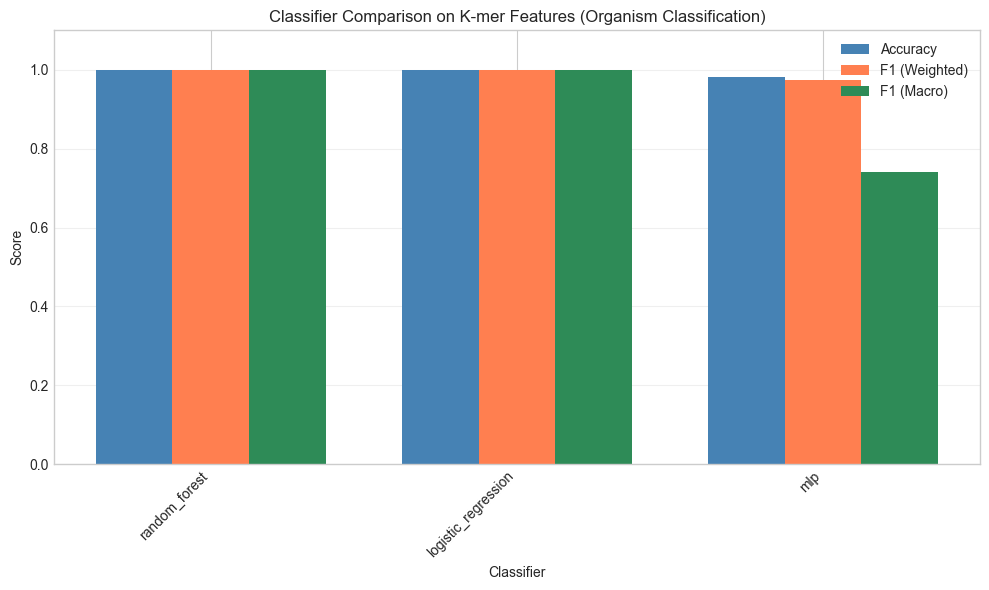

In [13]:
# Visualize results
if DATA_LOADED and 'results_df' in dir():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(results_df))
    width = 0.25
    
    ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
    ax.bar(x, results_df['F1 (Weighted)'], width, label='F1 (Weighted)', color='coral')
    ax.bar(x + width, results_df['F1 (Macro)'], width, label='F1 (Macro)', color='seagreen')
    
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Score')
    ax.set_title('Classifier Comparison on K-mer Features (Organism Classification)')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Classifier'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Inference Pipeline

End-to-end prediction pipeline for new genome sequences.

In [14]:
class AMRInferencePipeline:
    """
    End-to-end inference pipeline for AMR prediction.
    
    This pipeline:
    1. Takes a genome FASTA file as input
    2. Extracts features using HuggingFace models
    3. Predicts organism and AMR phenotypes
    4. Returns clinical interpretation
    """
    
    def __init__(self,
                 organism_classifier = None,
                 amr_classifier = None,
                 organism_classes: List[str] = None,
                 drug_classes: List[str] = None,
                 use_esm2: bool = True,
                 esm2_size: str = '8M'):
        """
        Initialize inference pipeline.
        
        Args:
            organism_classifier: Trained organism classifier
            amr_classifier: Trained AMR classifier
            organism_classes: List of organism class names
            drug_classes: List of drug class names
            use_esm2: Use ESM-2 for feature extraction
            esm2_size: ESM-2 model size
        """
        self.organism_classifier = organism_classifier
        self.amr_classifier = amr_classifier
        self.organism_classes = organism_classes or []
        self.drug_classes = drug_classes or []
        
        # Feature extractor
        self.feature_extractor = None
        if use_esm2 and TRANSFORMERS_AVAILABLE:
            self.feature_extractor = GenomicFeatureExtractor(
                use_esm2=True, 
                use_dnabert2=False,
                esm2_size=esm2_size
            )
    
    def predict(self, genome_path: str, amr_threshold: float = 0.5) -> Dict:
        """
        Make predictions for a genome.
        
        Args:
            genome_path: Path to FASTA file
            amr_threshold: Threshold for AMR resistance prediction
            
        Returns:
            Dictionary with predictions and interpretation
        """
        result = {
            'genome_path': str(genome_path),
            'timestamp': datetime.now().isoformat(),
            'organism': None,
            'amr_predictions': {},
            'clinical_summary': None,
            'error': None
        }
        
        try:
            # Extract features
            if self.feature_extractor:
                features = self.feature_extractor.extract_features(genome_path)
                if features is None:
                    result['error'] = "Failed to extract features from genome"
                    return result
                
                X = features['features'].reshape(1, -1)
                result['genome_length'] = features['genome_length']
                result['n_proteins'] = features['n_proteins']
            else:
                result['error'] = "Feature extractor not available"
                return result
            
            # Organism prediction
            if self.organism_classifier and len(self.organism_classes) > 0:
                org_pred = self.organism_classifier.predict(X)[0]
                org_proba = self.organism_classifier.predict_proba(X)[0]
                
                result['organism'] = {
                    'predicted': self.organism_classes[org_pred],
                    'confidence': float(org_proba[org_pred]),
                    'all_probabilities': {
                        cls: float(p) for cls, p in zip(self.organism_classes, org_proba)
                    }
                }
            
            # AMR prediction
            if self.amr_classifier and len(self.drug_classes) > 0:
                amr_proba = self.amr_classifier.predict_proba(X)[0]
                amr_pred = (amr_proba > amr_threshold).astype(int)
                
                result['amr_predictions'] = {
                    drug: {
                        'resistant': bool(pred),
                        'probability': float(prob)
                    }
                    for drug, pred, prob in zip(self.drug_classes, amr_pred, amr_proba)
                }
                
                # Clinical summary
                resistant_drugs = [d for d, p in result['amr_predictions'].items() if p['resistant']]
                susceptible_drugs = [d for d, p in result['amr_predictions'].items() if not p['resistant']]
                
                result['clinical_summary'] = {
                    'resistant_count': len(resistant_drugs),
                    'susceptible_count': len(susceptible_drugs),
                    'resistant_to': resistant_drugs,
                    'susceptible_to': susceptible_drugs,
                    'multi_drug_resistant': len(resistant_drugs) >= 3
                }
        
        except Exception as e:
            result['error'] = str(e)
        
        return result
    
    def format_report(self, prediction: Dict) -> str:
        """
        Format prediction as a clinical report.
        
        Args:
            prediction: Prediction dictionary from predict()
            
        Returns:
            Formatted report string
        """
        lines = [
            "=" * 60,
            "AMR PREDICTION REPORT",
            "=" * 60,
            f"Date: {prediction['timestamp']}",
            f"Genome: {Path(prediction['genome_path']).name}",
            ""
        ]
        
        if prediction['error']:
            lines.append(f"ERROR: {prediction['error']}")
            return "\n".join(lines)
        
        if 'genome_length' in prediction:
            lines.append(f"Genome Length: {prediction['genome_length']:,} bp")
            lines.append(f"Proteins Found: {prediction['n_proteins']}")
            lines.append("")
        
        if prediction['organism']:
            lines.extend([
                "-" * 40,
                "ORGANISM IDENTIFICATION",
                "-" * 40,
                f"Predicted: {prediction['organism']['predicted']}",
                f"Confidence: {prediction['organism']['confidence']:.1%}",
                ""
            ])
        
        if prediction['amr_predictions']:
            lines.extend([
                "-" * 40,
                "ANTIMICROBIAL RESISTANCE",
                "-" * 40,
            ])
            
            for drug, info in prediction['amr_predictions'].items():
                status = "RESISTANT" if info['resistant'] else "Susceptible"
                lines.append(f"  {drug}: {status} ({info['probability']:.1%})")
            
            lines.append("")
        
        if prediction['clinical_summary']:
            summary = prediction['clinical_summary']
            lines.extend([
                "-" * 40,
                "CLINICAL SUMMARY",
                "-" * 40,
                f"Resistant to: {summary['resistant_count']} drug classes",
                f"Susceptible to: {summary['susceptible_count']} drug classes",
            ])
            
            if summary['multi_drug_resistant']:
                lines.append("\n*** MULTI-DRUG RESISTANT ORGANISM ***")
            
            if summary['susceptible_to']:
                lines.append(f"\nRecommended antibiotics: {', '.join(summary['susceptible_to'][:3])}")
        
        lines.append("\n" + "=" * 60)
        
        return "\n".join(lines)

print("AMRInferencePipeline class defined.")

AMRInferencePipeline class defined.


## 8. Model Export

Save models and configurations for deployment.

In [15]:
# Save model configuration
model_config = {
    'timestamp': datetime.now().isoformat(),
    'esm2_models': ESM2_MODELS,
    'dnabert2_model': DNABERT2_MODEL,
    'selected_esm2_size': SELECTED_ESM2_SIZE,
    'feature_extraction': {
        'esm2_available': TRANSFORMERS_AVAILABLE,
        'dnabert2_available': TRANSFORMERS_AVAILABLE,
        'device': str(DEVICE) if TORCH_AVAILABLE else 'cpu'
    },
    'data_info': {
        'organism_classes': organism_metadata['class_names'] if DATA_LOADED else [],
        'drug_classes': amr_metadata['class_names'] if DATA_LOADED else []
    }
}

config_path = MODELS_DIR / 'huggingface' / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)

print(f"Model configuration saved to: {config_path}")
print("\nConfiguration:")
print(json.dumps(model_config, indent=2))

Model configuration saved to: /Users/jubayer/Projects/DeepAMR/models/huggingface/model_config.json

Configuration:
{
  "timestamp": "2026-01-26T10:59:02.501284",
  "esm2_models": {
    "8M": "facebook/esm2_t6_8M_UR50D",
    "35M": "facebook/esm2_t12_35M_UR50D",
    "150M": "facebook/esm2_t30_150M_UR50D",
    "650M": "facebook/esm2_t33_650M_UR50D",
    "3B": "facebook/esm2_t36_3B_UR50D"
  },
  "dnabert2_model": "zhihan1996/DNABERT-2-117M",
  "selected_esm2_size": "35M",
  "feature_extraction": {
    "esm2_available": false,
    "dnabert2_available": false,
    "device": "mps"
  },
  "data_info": {
    "organism_classes": [
      "Acinetobacter baumannii",
      "Enterococcus faecalis",
      "Enterococcus faecium",
      "Escherichia coli",
      "Klebsiella pneumoniae",
      "Pseudomonas aeruginosa",
      "Salmonella enterica",
      "Staphylococcus aureus"
    ],
    "drug_classes": [
      "aminoglycoside",
      "beta-lactam",
      "fosfomycin",
      "glycopeptide",
      "macro

In [16]:
# Summary
print("="*60)
print("HUGGINGFACE MODEL EXPLORATION COMPLETE")
print("="*60)

print("\n--- Available Models ---")
print("ESM-2 (Protein Language Model):")
for size, name in ESM2_MODELS.items():
    print(f"  {size}: {name}")

print(f"\nDNABERT-2: {DNABERT2_MODEL}")

print("\n--- Key Classes Implemented ---")
print("1. ESM2FeatureExtractor - Protein sequence embeddings")
print("2. DNABERT2FeatureExtractor - DNA sequence embeddings")
print("3. GenomicFeatureExtractor - Combined extraction pipeline")
print("4. HuggingFaceAMRClassifier - AMR prediction classifier")
print("5. AMRInferencePipeline - End-to-end prediction")

print("\n--- Next Steps ---")
print("1. Download full genomes and extract HuggingFace embeddings")
print("2. Train classifiers on HuggingFace embeddings")
print("3. Compare with k-mer based approach")
print("4. Deploy best model via FastAPI")
print("5. Integrate with frontend application")

HUGGINGFACE MODEL EXPLORATION COMPLETE

--- Available Models ---
ESM-2 (Protein Language Model):
  8M: facebook/esm2_t6_8M_UR50D
  35M: facebook/esm2_t12_35M_UR50D
  150M: facebook/esm2_t30_150M_UR50D
  650M: facebook/esm2_t33_650M_UR50D
  3B: facebook/esm2_t36_3B_UR50D

DNABERT-2: zhihan1996/DNABERT-2-117M

--- Key Classes Implemented ---
1. ESM2FeatureExtractor - Protein sequence embeddings
2. DNABERT2FeatureExtractor - DNA sequence embeddings
3. GenomicFeatureExtractor - Combined extraction pipeline
4. HuggingFaceAMRClassifier - AMR prediction classifier
5. AMRInferencePipeline - End-to-end prediction

--- Next Steps ---
1. Download full genomes and extract HuggingFace embeddings
2. Train classifiers on HuggingFace embeddings
3. Compare with k-mer based approach
4. Deploy best model via FastAPI
5. Integrate with frontend application
